# Do other models' translations agree? A consensus metric for NL→FOL faithfulness

**Experiment 3 (candidate C) — demo notebook.**

We want to know whether a first-order-logic (FOL) formula faithfully says what an English sentence says, **without a gold formula**. The idea tested here is **cross-system consensus**. Take a candidate formalization `c` of a sentence `t`, and ask several *other* translation systems to formalize `t` too. Then check with the **z3** SMT solver which of their outputs are logically equivalent to `c`, allowing for different vocabulary. If most of them disagree with `c`, then `c` is probably wrong.

Scores computed per candidate (higher = more likely an error):

| score | definition |
|---|---|
| `c_score` (primary) | `1 - eq_frac`: share of the *other* systems' translations that are **not** z3-equivalent to `c` modulo vocabulary (leave-one-system-out) |
| `medoid_depth` | minimal typed-repair distance (0–3) from `c` to the pool *medoid* (the translation with the most equivalent partners) |
| `cluster_entropy` | semantic entropy over the z3-equivalence classes of pool ∪ {c} |
| `c_score_peers6` / `_nonoai` / `_llm2` | the same as `c_score`, with the pool restricted to the 6 fresh peers / the 5 non-OpenAI peers / the other Logic-LM systems |
| `sc5_cheap`, `sc5_same` | **baselines**: sampling self-consistency, i.e. `1 -` the share of K=5 samples (gpt-4.1-nano, or gpt-3.5-turbo for gpt-3.5 candidates) equivalent to `c` |
| `predset_instab_*`, `fol_length` | **baselines**: predicate-set Jaccard instability, number of atoms |

**The pool** contains 6 OpenRouter model families (llama-3.3-70b, qwen3-235b, deepseek-v3.1, mistral-small-3.2, gemini-2.5-flash-lite, gpt-4.1-mini) plus the 3 released Logic-LM systems (gpt-3.5-turbo, gpt-4, text-davinci-003).

**Ground truth.** Candidates are the Logic-LM FOLIO outputs ("track L"). Each is labelled CORRECT or ERROR by prover-checked equivalence to *curated* gold, after vocabulary alignment. An ERROR label also records the minimal typed repair (NEG, DROP, ADD, QUANT, ...).

**Full-run result** (546 candidates, sentence-clustered bootstrap): `c_score` AUROC **0.866 [0.821, 0.906]**, against 0.725 for K=5 self-consistency.

**What this notebook does.** The original `method.py` is a thin driver that runs the pipeline modules in `src/` as subprocesses: labelling, OpenRouter calls, pairwise z3 equivalence, consensus scoring, and analysis. The notebook inlines the modules that do the actual measurement and runs them on a **35-sentence / 100-labelled-candidate subset**. The OpenRouter translations are **pre-recorded** in the data file, so no API key is needed. Every z3 equivalence, medoid repair and score is **recomputed live**.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# numpy, pandas, sklearn, scipy, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

These are the union of the import blocks of `method.py`, `src/fol.py`, `src/repair_census.py`, `src/common.py`, `src/consensus.py` and `src/analysis.py`. The `sys.path` manipulation and the cross-module `from X import ...` lines are dropped, because all the code now lives in this notebook. `matplotlib` is added for the final plots.

In [2]:
from __future__ import annotations

import hashlib
import itertools
import json
import math
import random
import re
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import z3
from loguru import logger
from scipy.stats import rankdata, spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve
from sklearn.model_selection import GroupKFold

import matplotlib.pyplot as plt

sys.setrecursionlimit(10000)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Load the demo data

`mini_demo_data.json` is a sentence-level subset of the frozen screen. It holds everything the consensus stage reads:

- `screen_items`: candidates with their text, candidate FOL, curated reference FOL and frozen label
- `peer_outputs`: the 6 OpenRouter peers' translations
- `sc_samples`: 5 gpt-4.1-nano and 5 gpt-3.5-turbo samples
- `units` / `premise_unit`: which FOLIO story or MALLS item each sentence came from
- `full_run_scores`: the full run's recorded scores, for comparison

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_Jhw6i0bFXdo3/round-1/experiment-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print({k: len(v) for k, v in data.items() if isinstance(v, (list, dict))})

Subset of the frozen NL->FOL screen (FOLIO-val / MALLS-test, curated gold) used by experiment 3: 35 sentences, 100 track-L candidates labelled CORRECT/ERROR, plus every peer / self-consistency translation of those sentences (6 OpenRouter peers P1-P6, 5 gpt-4.1-nano samples, 5 gpt-3.5-turbo samples).
{'headline_full_run': 13, 'screen_items': 141, 'units': 31, 'premise_unit': 19, 'peer_outputs': 417, 'sc_samples': 403, 'full_run_scores': 141}


## Configuration

These are all the tunable parameters. The original values are given in the comments (from `method.py` / `run_all.sh`: `consensus.py --budget 10`, `analysis.py --boot 2000`, and the `label()` search budget of 25 s). Every parameter runs at its original value. The only reduction is the data: 35 sentences (100 labelled candidates) instead of the full screen's 440 sentences (546 labelled candidates). The whole analysis takes under a minute; the install cell dominates the runtime.

In [5]:
N_SENTENCES = 35             # sentences scored (all 35 in mini_demo_data.json; full run: 440 sentences, 1,169 candidates, 546 of them labelled track-L CORRECT/ERROR)
MEDOID_REPAIR_BUDGET = 10.0  # seconds per candidate->medoid typed-repair search (original: --budget 10.0)
BOOT = 2000                  # sentence-clustered bootstrap resamples for AUROC CIs (original: --boot 2000)
N_LABEL_CHECK = 100          # candidates whose frozen label is re-derived live with label() (original: all, in screen.py)
LABEL_BUDGET = 25.0          # repair-search budget (s) inside label() (original: 25.0)

## 1. FOL parser and z3 bridge (`src/fol.py`, verbatim)

The parser reads Unicode FOL in FOLIO/MALLS notation into a small AST of tuples: `("atom", name, args)`, `("not", e)`, `("and"|"or"|"imp"|"iff"|"xor", a, b)`, `("all"|"ex", var, body)`. `to_z3` turns the AST into a z3 formula over one uninterpreted sort `U`. `equivalent(e1, e2)` is **valid(e1 ↔ e2)**, and the result is True, False, or None when z3 times out. Every equivalence judgement in the experiment rests on this function.

`profile`, `connectivity_flags` and the related functions are unused by this experiment. They are kept because they are part of the original module.

In [6]:
"""Unicode FOL (FOLIO/MALLS notation) -> AST -> z3; semantic monotonicity profile per predicate.

Grammar (lowest to highest precedence): ↔  <  →  <  ∨ / ⊕  <  ∧  <  ¬, quantifiers, atoms.
(iter-1 GEN_ART fix: ⊕ now binds like ∨, i.e. tighter than →, so "A ⊕ B → C" is "(A ⊕ B) → C";
 the iter-3 probe version gave ⊕ the precedence of ↔, which created false COMPOUND census classes.)
A quantifier binds the immediately following parenthesised group, atom, negation or quantifier
(FOLIO/MALLS convention: '∀x (A(x)) ∧ ∀y (B(y))' is two sentences).
"""
TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")
OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}
PREC = {"iff": 1, "imp": 2, "xor": 3, "or": 3, "and": 4}


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("->", "→").replace("<->", "↔").replace("&", "∧").replace("|", "∨")
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def parse(s: str):
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def profile(e, ms=3000):
    """Semantic monotonicity of formula e in each predicate: UP / DOWN / VACUOUS / NONMONO / UNKNOWN."""
    ar = preds(e)
    base = {q: mkpred(q, m) for q, m in ar.items()}
    out = {}
    for p, n in ar.items():
        alt = dict(base)
        alt[p] = mkpred(p + "_prime", n)
        xs = [z3.Const(f"_x{i}", U) for i in range(n)]
        sub = z3.ForAll(xs, z3.Implies(base[p](*xs), alt[p](*xs))) if n else z3.Implies(base[p], alt[p])
        F, Fp = to_z3(e, {}, base), to_z3(e, {}, alt)
        up, down = valid(z3.Implies(z3.And(sub, F), Fp), ms), valid(z3.Implies(z3.And(sub, Fp), F), ms)
        if up is None or down is None:
            out[p] = "UNKNOWN"
        else:
            out[p] = {(True, True): "VACUOUS", (True, False): "UP", (False, True): "DOWN", (False, False): "NONMONO"}[(up, down)]
    return out


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)

## 2. Vocabulary alignment, granularity bridge and typed repair search (`src/repair_census.py`)

Two correct translations rarely use the same predicate names. Equivalence is therefore checked **modulo vocabulary**:

- **`align(old, new)`**: renames predicates and constants of `old` onto those of `new` with the same arity, when their CamelCase-token Jaccard is ≥ 0.5, or their char-trigram Dice is ≥ 0.6 (≥ 0.7 for constants).
- **`gran_bridge`**: adds definitional merge/split bridges, e.g. `WorksInNewsAndReports(x) := WorksInNews(x) ∧ Reports(x)`, and reification bridges `P(x) := Q(x, c)`.
- **`fp`**: a cheap random-model *fingerprint*, used as a sound necessary-condition pre-filter before calling z3. Equivalent formulas always have equal fingerprints.
- **`search`**: a breadth-first search, depth ≤ 2, over *typed edit operators*: NEG, REV, QUANT, RESTR, CONN, DROP, ADD, SWAP, BIND, SCOPE, UNGLUE, MOVE. It finds the minimal repair that makes one formula equivalent to another. The labeller uses it to type errors against the gold, and the consensus metric uses it to type the distance from a candidate to the pool medoid.

This cell copies the module's functions verbatim. The census driver at the bottom of the module (`load`, `pairs`, `work`, `main`) is left out, because it reads a separate iter-3 dataset that this experiment does not use.

In [7]:
TOKRE = re.compile(r"[A-Z]?[a-z]+|[A-Z]+(?![a-z])|\d+")
STOP = {"and", "or", "of", "in", "on", "the", "a", "an", "to", "is", "has", "have", "can", "for", "with", "by", "at", "from", "be", "are"}
BIN = ("and", "or", "imp", "iff", "xor")


def toks(name):
    out = []
    for w in TOKRE.findall(name.replace("_", " ")):
        w = w.lower()
        if w in STOP:
            continue
        out.append(w[:-1] if w.endswith("s") and len(w) > 3 else w)
    return out


def tri(s):
    s = re.sub(r"[^a-z0-9]", "", s.lower())
    return {s[i:i + 3] for i in range(max(1, len(s) - 2))}


def dice(a, b):
    A, B = tri(a), tri(b)
    return 2 * len(A & B) / max(1, len(A) + len(B))


# ---------------------------------------------------------------- AST utilities
def atoms(e, acc=None):
    acc = [] if acc is None else acc
    if e[0] == "atom":
        acc.append(e)
    elif e[0] in ("all", "ex"):
        atoms(e[2], acc)
    elif e[0] == "not":
        atoms(e[1], acc)
    else:
        atoms(e[1], acc); atoms(e[2], acc)
    return acc


def bound_vars(e, acc=None):
    acc = set() if acc is None else acc
    if e[0] in ("all", "ex"):
        acc.add(e[1]); bound_vars(e[2], acc)
    elif e[0] == "not":
        bound_vars(e[1], acc)
    elif e[0] != "atom":
        bound_vars(e[1], acc); bound_vars(e[2], acc)
    return acc


def symbols(e):
    bv = bound_vars(e)
    P, C = {}, set()
    for a in atoms(e):
        P[(a[1], len(a[2]))] = True
        for x in a[2]:
            if x not in bv:
                C.add(x)
    return set(P), C


def rename(e, pmap, cmap, bv=frozenset()):
    k = e[0]
    if k == "atom":
        return ("atom", pmap.get((e[1], len(e[2])), e[1]), tuple(x if x in bv else cmap.get(x, x) for x in e[2]))
    if k in ("all", "ex"):
        return (k, e[1], rename(e[2], pmap, cmap, bv | {e[1]}))
    if k == "not":
        return ("not", rename(e[1], pmap, cmap, bv))
    return (k, rename(e[1], pmap, cmap, bv), rename(e[2], pmap, cmap, bv))


def expand(e, defs):
    """defs: {(name, arity): [name1, name2]}  P(args) -> Q1(args) & Q2(args)"""
    k = e[0]
    if k == "atom":
        key = (e[1], len(e[2]))
        if key in defs:
            q = defs[key]
            out = ("atom", q[0], e[2])
            for n in q[1:]:
                out = ("and", out, ("atom", n, e[2]))
            return out
        return e
    if k in ("all", "ex"):
        return (k, e[1], expand(e[2], defs))
    if k == "not":
        return ("not", expand(e[1], defs))
    return (k, expand(e[1], defs), expand(e[2], defs))


def align(old, new):
    Po, Co = symbols(old)
    Pn, Cn = symbols(new)
    pmap, used = {}, set()
    cands = []
    for p in Po - Pn:
        for q in Pn - Po:
            if p[1] != q[1]:
                continue
            to, tn = set(toks(p[0])), set(toks(q[0]))
            j = len(to & tn) / max(1, len(to | tn))
            s = max(j, dice(p[0], q[0]))
            if p[0].lower() == q[0].lower():
                s = 2
            if j >= 0.5 or dice(p[0], q[0]) >= 0.6 or s == 2:
                cands.append((s, p, q))
    for s, p, q in sorted(cands, reverse=True):
        if p in pmap or q in used:
            continue
        pmap[p] = q[0]; used.add(q)
    cmap, cused = {}, set()
    norm = lambda s: re.sub(r"[^a-z0-9]", "", s.lower())
    for c in Co - Cn:
        best = None
        for d in Cn - Co:
            if d in cused:
                continue
            a, b = norm(c), norm(d)
            if a == b or (min(len(a), len(b)) >= 4 and (a in b or b in a)) or dice(c, d) >= 0.7:
                best = d
                break
        if best:
            cmap[c] = best; cused.add(best)
    return rename(old, pmap, cmap), pmap, cmap


def gran_bridge(ao, new):
    """Try merge/split definitional bridges between leftover predicates of the aligned original and corrected."""
    Po, _ = symbols(ao)
    Pn, _ = symbols(new)
    lo, ln = Po - Pn, Pn - Po
    defs_old, defs_new = {}, {}
    for p in lo:  # original merged predicate -> corrected split pair
        tp = sorted(toks(p[0]))
        for q1, q2 in itertools.combinations([q for q in ln if q[1] == p[1]], 2):
            if sorted(toks(q1[0]) + toks(q2[0])) == tp or set(toks(q1[0]) + toks(q2[0])) == set(tp):
                defs_old[p] = [q1[0], q2[0]]
    for q in ln:  # corrected merged predicate -> original split pair
        tq = sorted(toks(q[0]))
        for p1, p2 in itertools.combinations([p for p in lo if p[1] == q[1]], 2):
            if sorted(toks(p1[0]) + toks(p2[0])) == tq or set(toks(p1[0]) + toks(p2[0])) == set(tq):
                defs_new[q] = [p1[0], p2[0]]
    _, Cn = symbols(new)
    reify = {}
    for p in lo:  # P(x) := Q(x, c) when tokens(P) == tokens(Q) + tokens(c)
        for q in ln:
            if q[1] != p[1] + 1:
                continue
            for c in Cn:
                if set(toks(q[0]) + toks(c)) == set(toks(p[0])):
                    reify[p] = (q[0], c)
    if not defs_old and not defs_new and not reify:
        return None
    return reify_expand(expand(ao, defs_old), reify), expand(new, defs_new)


def reify_expand(e, reify):
    k = e[0]
    if k == "atom":
        key = (e[1], len(e[2]))
        if key in reify:
            q, c = reify[key]
            return ("atom", q, e[2] + (c,))
        return e
    if k in ("all", "ex"):
        return (k, e[1], reify_expand(e[2], reify))
    if k == "not":
        return ("not", reify_expand(e[1], reify))
    return (k, reify_expand(e[1], reify), reify_expand(e[2], reify))


# ---------------------------------------------------------------- random-model fingerprint (necessary condition)
SEEDS = list(range(24))


def ev(e, m, env, dom, seed):
    k = e[0]
    if k == "atom":
        args = tuple(env[x] if x in env else (hash((seed, "c", x)) % dom) for x in e[2])
        return (hash((seed, e[1], len(e[2]), args)) >> 3) & 1 == 1
    if k == "all":
        return all(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "ex":
        return any(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "not":
        return not ev(e[1], m, env, dom, seed)
    a, b = ev(e[1], m, env, dom, seed), ev(e[2], m, env, dom, seed)
    return {"and": a and b, "or": a or b, "imp": (not a) or b, "iff": a == b, "xor": a != b}[k]


def fp(e):
    return tuple(ev(e, None, {}, 3, s) for s in SEEDS)

In [8]:
# ---------------------------------------------------------------- typed operators
def subterms(e, path=(), scope=()):
    yield path, e, scope
    k = e[0]
    if k in ("all", "ex"):
        yield from subterms(e[2], path + (2,), scope + (e[1],))
    elif k == "not":
        yield from subterms(e[1], path + (1,), scope)
    elif k != "atom":
        yield from subterms(e[1], path + (1,), scope)
        yield from subterms(e[2], path + (2,), scope)


def replace(e, path, new):
    if not path:
        return new
    i = path[0]
    lst = list(e)
    lst[i] = replace(e[i], path[1:], new)
    return tuple(lst)


def parent_kind(e, path):
    if not path:
        return None
    x = e
    for i in path[:-1]:
        x = x[i]
    return x[0]


def unglue(node):
    """∀x∀y (A(x) ∧ B(y) → C(x) ∧ D(y))  ->  ∀x (A(x) → C(x)) ∧ ∀y (B(y) → D(y))"""
    vs, body = [], node
    while body[0] == "all":
        vs.append(body[1]); body = body[2]
    if len(vs) < 2 or body[0] != "imp":
        return None

    def conj(x):
        return conj(x[1]) + conj(x[2]) if x[0] == "and" else [x]

    def vars_of(x):
        return {a for at in atoms(x) for a in at[2] if a in vs}
    ant, con = conj(body[1]), conj(body[2])
    groups = []
    for v in vs:
        a = [x for x in ant if vars_of(x) == {v}]
        c = [x for x in con if vars_of(x) == {v}]
        if not c:
            return None
        groups.append((v, a, c))
    if sum(len(g[1]) for g in groups) != len(ant) or sum(len(g[2]) for g in groups) != len(con):
        return None

    def mk(lst, op="and"):
        out = lst[0]
        for x in lst[1:]:
            out = (op, out, x)
        return out
    parts = [("all", v, ("imp", mk(a), mk(c)) if a else mk(c)) for v, a, c in groups]
    return mk(parts)


def edits(e, target):
    """Yield (op_label, candidate) for every single typed edit of e."""
    tgt_atoms = atoms(target)
    Pe, _ = symbols(e)
    _, Ct = symbols(target)
    new_atoms = [a for a in tgt_atoms if (a[1], len(a[2])) not in Pe]
    for path, node, scope in list(subterms(e)):
        k = node[0]
        # NEG
        if k == "not":
            yield "NEG", replace(e, path, node[1])
        else:
            yield "NEG", replace(e, path, ("not", node))
        if k in ("all", "ex"):
            yield "QUANT", replace(e, path, ("ex" if k == "all" else "all", node[1], node[2]))
            # block flip with the restrictor convention: ∀x∀y(A→B) <-> ∃x∃y(A∧B)
            vs, body = [], node
            while body[0] == k:
                vs.append(body[1]); body = body[2]
            if body[0] in ("imp", "and"):
                nb = ("and" if body[0] == "imp" else "imp", body[1], body[2])
                q = "ex" if k == "all" else "all"
                for v in reversed(vs):
                    nb = (q, v, nb)
                yield "QUANT", replace(e, path, nb)
            if node[2][0] in ("all", "ex"):
                inner = node[2]
                yield "SCOPE", replace(e, path, (inner[0], inner[1], (k, node[1], inner[2])))
            ug = unglue(node) if k == "all" else None
            if ug is not None:
                yield "UNGLUE", replace(e, path, ug)
        if k in ("imp", "iff") and node[1][0] == "and":
            # MOVE: pull a conjunct of the left side out as an outer restriction: (A ∧ B op C) -> (A -> (B op C))
            yield "MOVE", replace(e, path, ("imp", node[1][1], (k, node[1][2], node[2])))
            yield "MOVE", replace(e, path, ("imp", node[1][2], (k, node[1][1], node[2])))
        if k == "imp" and node[2][0] == "imp":
            # MOVE inverse: A -> (B -> C)  <->  (A ∧ C) -> B style condition/consequence exchange
            yield "MOVE", replace(e, path, ("imp", ("and", node[1], node[2][2]), node[2][1]))
        if k in BIN:
            if k == "imp":
                yield "REV", replace(e, path, ("imp", node[2], node[1]))
            for op in BIN:
                if op != k:
                    lab = "RESTR" if {k, op} == {"imp", "and"} and parent_kind(e, path) in ("all", "ex") else "CONN"
                    yield lab, replace(e, path, (op, node[1], node[2]))
            if k in ("and", "or"):
                yield "DROP", replace(e, path, node[1])
                yield "DROP", replace(e, path, node[2])
        if k == "atom":
            args = node[2]
            if len(args) >= 2:
                for perm in set(itertools.permutations(args)):
                    if perm != args:
                        yield "SWAP", replace(e, path, ("atom", node[1], perm))
            pool = set(scope) | Ct
            for i, a in enumerate(args):
                for b in pool:
                    if b != a:
                        yield "BIND", replace(e, path, ("atom", node[1], args[:i] + (b,) + args[i + 1:]))
        # ADD: conjoin a corrected-only atom (args re-bound to in-scope variables when its variables are foreign)
        if k != "atom" or True:
            for a in new_atoms:
                sc = list(scope)
                opts = []
                for x in a[2]:
                    opts.append([x] if (x in Ct or x in sc) else (sc or [x]))
                for combo in itertools.islice(itertools.product(*opts), 6):
                    yield "ADD", replace(e, path, ("and", node, ("atom", a[1], tuple(combo))))


def search(ao, target, budget_s=25.0, max_d2=6000):
    ft = fp(target)
    t0 = time.time()
    lvl1 = []
    seen = set()
    for lab, c in edits(ao, target):
        s = str(c)
        if s in seen:
            continue
        seen.add(s)
        lvl1.append((lab, c))
        if fp(c) == ft and equivalent(c, target, ms=1500) is True:
            return [lab], time.time() - t0
    n = 0
    for lab1, c1 in lvl1:
        for lab2, c2 in edits(c1, target):
            n += 1
            if lab1 == "NEG" and lab2 == "NEG":
                continue
            if n > max_d2 * 10 or time.time() - t0 > budget_s:
                return None, time.time() - t0
            if fp(c2) == ft and equivalent(c2, target, ms=1500) is True:
                return sorted([lab1, lab2]), time.time() - t0
    return None, time.time() - t0

## 3. Shared primitives: the labeller, `eqmv`, strata and medoid repair (`src/common.py`, verbatim)

- **`label(cand, ref)`** is the *automatic ground-truth labeller*. It runs in stages:
  - exact z3 equivalence to the curated gold → `CORRECT/EQUIV`
  - equivalence after `align()` → `CORRECT/VOCAB`
  - equivalence after a merge/split bridge → `UNCERTAIN_GRAN`
  - a depth ≤ 2 typed repair found → `ERROR[ops]`
  - otherwise → `UNCERTAIN_COMPOUND`

  The primary contrast uses only `CORRECT` and `ERROR`.
- **`eqmv(a, b)`** is *symmetric equivalence modulo vocabulary*: exact equivalence, else `align()` in either direction, else `gran_bridge`. **This is the only primitive the consensus metric uses.** It needs no gold.
- **`strata`** computes the complexity bins (words, quantifiers, nesting depth, conditions, exception markers).
- **`medoid_repair`** gives the minimal typed repair from a candidate to the pool medoid.

In [9]:
"""Shared primitives of the frozen screen: text normalisation, item ids, the automatic labeller,
equivalence-modulo-vocabulary (eqmv) and the complexity strata.

The labeller reproduces the iter-3 repair census (repair_census.work) stage by stage, so the label
vector is identical to sibling experiments A/B/D and dataset E (EQUIV+VOCAB -> CORRECT,
GRAN -> UNCERTAIN_GRAN, depth<=2 repair -> ERROR[ops], no repair -> UNCERTAIN_COMPOUND).
"""
LLM_SYSTEMS = ["gpt-3.5-turbo", "gpt-4", "text-davinci-003"]
EXC_RE = re.compile(r"\b(unless|except|excluding|other than|apart from|but not|without)\b")
COARSE = {"ADD": "COVERAGE", "DROP": "COVERAGE", "NEG": "POLARITY", "REV": "POLARITY", "QUANT": "POLARITY"}


def norm(t: str) -> str:
    return re.sub(r"\s+", " ", re.sub(r"[^\w\s]", "", t.lower())).strip()


def item_id(system: str, text: str, fol: str) -> str:
    return hashlib.sha1((system + "|" + norm(text) + "|" + fol.strip()).encode()).hexdigest()[:16]


def safe_parse(s: str | None):
    if s is None or not str(s).strip():
        return None
    try:
        return parse(str(s))
    except (ValueError, IndexError, RecursionError, TypeError):
        return None


def vocab_strict(pmap: dict) -> bool:
    """Every renamed predicate pair has identical CamelCase token multisets."""
    return all(sorted(toks(k[0])) == sorted(toks(v)) for k, v in pmap.items())


def op_class(ops: list[str]) -> str:
    if not ops:
        return "NONE"
    cs = {COARSE.get(o, "STRUCT") for o in ops}
    return cs.pop() if len(cs) == 1 else "MIXED"


def label(cand: str, ref: str, ambiguous: bool = False, track: str = "L", budget_s: float = 25.0) -> dict:
    """LABEL(cand, ref, ambiguous) -> {label, auto_class, repair_ops, vocab_strict, pmap}.

    Stage order and z3 timeouts are those of repair_census.work (equivalent() default ms=5000)."""
    out = {"label": None, "auto_class": None, "repair_ops": [], "vocab_strict": None, "pmap": {}}
    ce, re_ = safe_parse(cand), safe_parse(ref)
    if re_ is None:
        out.update(label="REF_UNPARSEABLE", auto_class="REF_UNPARSEABLE")
        return out
    if ce is None:
        out.update(label="UNPARSEABLE", auto_class="UNPARSEABLE")
        return _reading(out, ambiguous, track)
    timeouts = False
    r = equivalent(ce, re_)
    if r is True:
        out.update(label="CORRECT", auto_class="EQUIV", vocab_strict=True)
        return out
    timeouts |= r is None
    ac, pmap, cmap = align(ce, re_)
    out["pmap"] = {f"{k[0]}/{k[1]}": v for k, v in pmap.items()}
    r = equivalent(ac, re_)
    if r is True:
        out.update(label="CORRECT", auto_class="VOCAB", vocab_strict=vocab_strict(pmap))
        return out
    timeouts |= r is None
    gb = gran_bridge(ac, re_)
    if gb:
        r = equivalent(gb[0], gb[1])
        if r is True:
            out.update(label="UNCERTAIN_GRAN", auto_class="GRAN")
            return _reading(out, ambiguous, track)
        timeouts |= r is None
    if timeouts:
        out.update(label="TIMEOUT_UNKNOWN", auto_class="TIMEOUT")
        return _reading(out, ambiguous, track)
    base, tgt = gb if gb else (ac, re_)
    ops, _ = search(base, tgt, budget_s=budget_s)
    if ops:
        out.update(label="ERROR", auto_class="+".join(ops), repair_ops=list(ops))
    else:
        out.update(label="UNCERTAIN_COMPOUND", auto_class="COMPOUND")
    return _reading(out, ambiguous, track)


def _reading(out: dict, ambiguous: bool, track: str) -> dict:
    """Track H: curator-flagged ambiguous items that are not CORRECT become READING_CHOICE."""
    if track == "H" and ambiguous and out["label"] != "CORRECT":
        out["underlying_label"] = out["label"]
        out["label"] = "READING_CHOICE"
    return out


# ------------------------------------------------------------------ equivalence modulo vocabulary
def _eq(a, b, ms):
    """z3 equivalence with the random-model fingerprint as a sound necessary-condition pre-filter."""
    if fp(a) != fp(b):
        return False
    return equivalent(a, b, ms=ms)


def eqmv(a, b, ms: int = 3000) -> tuple[bool | None, str]:
    """Symmetric equivalence modulo vocabulary: exact, then align() either direction, then gran_bridge."""
    to = False
    r = _eq(a, b, ms)
    if r is True:
        return True, "exact"
    to |= r is None
    for x, y in ((a, b), (b, a)):
        ax = align(x, y)[0]
        r = _eq(ax, y, ms)
        if r is True:
            return True, "align"
        to |= r is None
        gb = gran_bridge(ax, y)
        if gb:
            r = _eq(gb[0], gb[1], ms)
            if r is True:
                return True, "gran"
            to |= r is None
    return (None if to else False), "none"


# ------------------------------------------------------------------ strata
def _depth(e) -> int:
    k = e[0]
    if k == "atom":
        return 0
    if k in ("all", "ex"):
        return 1 + _depth(e[2])
    if k == "not":
        return 1 + _depth(e[1])
    return 1 + max(_depth(e[1]), _depth(e[2]))


def _count(e, kinds) -> int:
    k = e[0]
    n = 1 if k in kinds else 0
    if k == "atom":
        return n
    if k in ("all", "ex"):
        return n + _count(e[2], kinds)
    if k == "not":
        return n + _count(e[1], kinds)
    return n + _count(e[1], kinds) + _count(e[2], kinds)


def _conjuncts(e) -> int:
    return _conjuncts(e[1]) + _conjuncts(e[2]) if e[0] == "and" else 1


def _ncond(e) -> int:
    k = e[0]
    if k == "atom":
        return 0
    if k in ("all", "ex"):
        return _ncond(e[2])
    if k == "not":
        return _ncond(e[1])
    n = _conjuncts(e[1]) if k == "imp" else 0
    return n + _ncond(e[1]) + _ncond(e[2])


def strata(text: str, ref_fol: str) -> dict:
    words = len(text.split())
    e = safe_parse(ref_fol)
    m = EXC_RE.search(text.lower())
    out = {"words": words, "len_bin": "<12" if words < 12 else ("12-19" if words < 20 else ">=20"),
           "exception": bool(m), "exception_marker": m.group(1) if m else None}
    if e is None:
        out.update(n_quant=None, depth=None, n_cond=None)
    else:
        out.update(n_quant=_count(e, ("all", "ex")), depth=_depth(e), n_cond=_ncond(e))
    return out


def medoid_repair(c, m, budget_s: float = 10.0) -> tuple[int, list[str]]:
    """Minimal typed repair from candidate c to medoid m (after align + gran bridge)."""
    ac = align(c, m)[0]
    gb = gran_bridge(ac, m)
    base, tgt = gb if gb else (ac, m)
    ops, _ = search(base, tgt, budget_s=budget_s)
    return (len(ops), list(ops)) if ops else (3, ["COMPOUND"])


def alignable_frac(cand, ref) -> float | None:
    """Fraction of candidate predicates identical to, or align()-mapped onto, a reference predicate."""
    if cand is None or ref is None:
        return None
    pc, _ = symbols(cand)
    pr, _ = symbols(ref)
    if not pc:
        return 1.0
    _, pmap, _ = align(cand, ref)
    ok = sum(1 for p in pc if p in pr or p in pmap)
    return ok / len(pc)

### Quick sanity check: the labeller reproduces the frozen labels

We re-run `label()` live on a few track-L candidates and compare the result with the label frozen in the screen. The full screen's label vector is hashed (`0e43cbdd…`) and was pre-registered before any metric was scored. `LABEL_BUDGET` is the repair-search budget.

**Note on determinism.** The original pipeline runs every stage with `PYTHONHASHSEED=0`. A notebook kernel's hash seed is random, and a few set iterations in `align()` (and in the `fp` fingerprint) depend on it. So once in a while, one alignment can pick a different constant mapping than the frozen run did. In our tests, 99 or 100 of the 100 labels and `c_score` values matched, depending on the kernel session.

In [10]:
_chk = [x for x in data["screen_items"] if x["track"] == "L" and x["label"] in ("CORRECT", "ERROR")][:N_LABEL_CHECK]
_agree = 0
for x in _chk:
    lab = label(x["candidate_fol"], x["reference_fol"], budget_s=LABEL_BUDGET)
    _agree += lab["label"] == x["label"]
    print(f"{x['label']:8s} -> live {lab['label']:8s} {lab['auto_class']:12s} | {x['candidate_fol'][:70]}")
print(f"\nlive label == frozen label: {_agree}/{len(_chk)}")

ERROR    -> live ERROR    ADD          | In(missoula, montana)
CORRECT  -> live CORRECT  VOCAB        | ∀x (Digital(x) → ¬Analog(x))
ERROR    -> live ERROR    BIND         | SportingEvent(worldChampionships)
CORRECT  -> live CORRECT  EQUIV        | ∀x (FourSided(x) → Shape(x))
ERROR    -> live ERROR    ADD+DROP     | Name(surprisingAdventuresOfSirDigbyChickenCaesar, sirDigby)
CORRECT  -> live CORRECT  EQUIV        | ∀x (HouseholdAppliance(x) → Suck(x))
ERROR    -> live ERROR    ADD+DROP     | Participate(steinhauer, duMaurierClassic1992)
ERROR    -> live ERROR    ADD+DROP     | OliveGarden(theOliveGarden)
ERROR    -> live ERROR    NEG          | ¬Pet(ted)
CORRECT  -> live CORRECT  EQUIV        | ∀x (Striker(x) → SoccerPlayer(x))
CORRECT  -> live CORRECT  VOCAB        | ∃x (Orchestra(x) ∧ ∃y (MusicPiece(y) ∧ Premiere(x, y)))
ERROR    -> live ERROR    DROP         | ∀x (Person(x) ∧ Gain(x, knowledge) → Smarter(x))
CORRECT  -> live CORRECT  EQUIV        | ManagedBuilding(oliveGarden)
ERRO

ERROR    -> live ERROR    ADD+DROP     | ¬(GrewUp(taylor, healthConscious) ∨ VisitGym(taylor))
ERROR    -> live ERROR    ADD+DROP     | SpendTime(luke)
ERROR    -> live ERROR    ADD+DROP     | University(yale) ∧ Private(yale) ∧ IvyLeague(yale) ∧ Research(yale)
ERROR    -> live ERROR    ADD+DROP     | ¬Player(robert, bayernMunchen)
CORRECT  -> live CORRECT  VOCAB        | Romance(french) ∧ Romance(spanish)
ERROR    -> live ERROR    ADD+DROP     | University(yale) ∧ Private(yale) ∧ IvyLeague(yale) ∧ Research(yale)
CORRECT  -> live CORRECT  VOCAB        | ∀x (Gain(x, knowledge) → Smarter(x))
CORRECT  -> live CORRECT  EQUIV        | Leads(roderickStrong, creedBrothers)
CORRECT  -> live CORRECT  VOCAB        | Owner(tom)
ERROR    -> live ERROR    ADD+DROP     | Complains(luke)
ERROR    -> live ERROR    QUANT        | ¬∀x (Digital(x) → Analog(x))
ERROR    -> live ERROR    DROP         | Person(harry) ∧ Book(walden) ∧ Read(harry, walden)
CORRECT  -> live CORRECT  EQUIV        | Pet(ted)
ERROR

ERROR    -> live ERROR    SWAP         | ∀x (Book(x) ∧ Publish(newVesselPress, x) → English(x))
CORRECT  -> live CORRECT  VOCAB        | From(descampe, belgium) ∧ Leaderboard(descampe, duMaurierClassic1992)
CORRECT  -> live CORRECT  EQUIV        | ∃x (MountainRange(x) ∧ In(x, texas) ∧ Visited(juanDeOnate, x))
ERROR    -> live ERROR    CONN         | (MountainRange(picuris) ∧ (In(picuris, newMexico) ∨ In(picuris, texas)

live label == frozen label: 99/100


## 4. Pairwise equivalence and repair caches (`src/eqcache.py`, adapted)

The original caches store every pairwise `eqmv` verdict and every medoid repair in resumable `.jsonl` files, and compute them with a `multiprocessing` spawn pool. **This is the one structural change in the notebook.** Worker processes cannot import functions that are defined inside a notebook, so `compute()` here runs the same worker functions serially and keeps the cache in memory. The worker bodies, the cache keys and the `get`/`eq` logic are unchanged.

In [11]:
def key(a: str, b: str) -> tuple[str, str]:
    a, b = a.strip(), b.strip()
    return (a, b) if a <= b else (b, a)


def _pair_worker(chunk: list[tuple[str, str]]) -> list[dict]:
    out = []
    for a, b in chunk:
        t0 = time.time()
        ea, eb = safe_parse(a), safe_parse(b)
        if ea is None or eb is None:
            eq, route = None, "unparseable"
        elif a == b:
            eq, route = True, "identical"
        else:
            try:
                eq, route = eqmv(ea, eb)
            except (RecursionError, ValueError, KeyError, TypeError) as e:
                eq, route = None, f"error:{type(e).__name__}"
        out.append({"a": a, "b": b, "eq": eq, "route": route, "secs": round(time.time() - t0, 3)})
    return out


class PairCache:
    def __init__(self):
        self.d = {}  # original: loaded from results/pairwise_eq.jsonl

    def get(self, a: str, b: str) -> dict | None:
        k = key(a, b)
        if k[0] == k[1]:  # identical formula strings are trivially equivalent (never sent to the workers)
            return {"a": k[0], "b": k[1], "eq": True, "route": "identical", "secs": 0.0}
        return self.d.get(k)

    def eq(self, a: str, b: str):
        r = self.get(a, b)
        return None if r is None else r["eq"]

    def compute(self, pairs, workers: int = 4, chunk: int = 20, tag: str = ""):
        todo = sorted({key(a, b) for a, b in pairs if a and b} - set(self.d))
        if not todo:
            return
        logger.info(f"[{tag}] eqmv pairs to compute: {len(todo)} (cached {len(self.d)})")
        chunks = [todo[i:i + chunk] for i in range(0, len(todo), chunk)]
        t0 = time.time()
        for i, res in enumerate(map(_pair_worker, chunks)):  # original: spawn Pool(workers).imap_unordered + jsonl append
            for r in res:
                self.d[(r["a"], r["b"])] = r
            if (i + 1) % 50 == 0:
                el = time.time() - t0
                logger.info(f"[{tag}] {i + 1}/{len(chunks)} chunks, {el:.0f}s, eta {el / (i + 1) * (len(chunks) - i - 1):.0f}s")
        logger.info(f"[{tag}] done in {time.time() - t0:.0f}s")


def _repair_worker(chunk: list[tuple[str, str, float]]) -> list[dict]:
    out = []
    for c, m, budget in chunk:
        t0 = time.time()
        ec, em = safe_parse(c), safe_parse(m)
        if ec is None or em is None:
            d, ops = None, []
        else:
            try:
                d, ops = medoid_repair(ec, em, budget_s=budget)
            except (RecursionError, ValueError, KeyError, TypeError):
                d, ops = 3, ["COMPOUND"]
        out.append({"c": c, "m": m, "depth": d, "ops": ops, "secs": round(time.time() - t0, 2)})
    return out


class RepairCache:
    def __init__(self):
        self.d = {}  # original: loaded from results/repair_cache.jsonl

    def get(self, c: str, m: str) -> dict | None:
        return self.d.get((c.strip(), m.strip()))

    def compute(self, pairs, workers: int = 4, budget: float = 10.0, tag: str = ""):
        todo = sorted({(c.strip(), m.strip()) for c, m in pairs} - set(self.d))
        if not todo:
            return
        logger.info(f"[{tag}] medoid repairs to compute: {len(todo)} (budget {budget}s each)")
        t0 = time.time()
        for i, res in enumerate(map(_repair_worker, [[(c, m, budget)] for c, m in todo])):  # original: spawn Pool
            for r in res:
                self.d[(r["c"], r["m"])] = r
            if (i + 1) % 100 == 0:
                el = time.time() - t0
                logger.info(f"[{tag}] {i + 1}/{len(todo)} repairs, {el:.0f}s, eta {el / (i + 1) * (len(todo) - i - 1):.0f}s")
        logger.info(f"[{tag}] repairs done in {time.time() - t0:.0f}s")

## 5. The consensus metric (`src/consensus.py`, verbatim functions)

- **`build_sentences`** assembles, for every sentence, the **pool**: the 6 peers' parsed translations plus one Logic-LM output per system. It also collects the K=5 self-consistency samples of both SC arms, and the curated reference, which is used for labels only.
- **`score_candidate(cfol, own, S, pc)`** does the scoring. It drops the candidate's *own* system from the pool (leave-one-out). It then computes:
  - `eq_frac` over the full pool and over its sub-pools
  - the eqmv equivalence classes, via union-find in `components`, and their `entropy`
  - the **medoid**: the pool member with the most eqmv partners

  A z3 timeout counts as *not equivalent*. A pool with fewer than 2 parsed members is reported as `insufficient_pool`, and an unparseable candidate is reported as `candidate_unparseable`. Neither case is dropped silently.
- **`sc_scores`** is the self-consistency baseline: the share of the 5 samples that are eqmv to the candidate. A missing or unparseable sample counts as not equivalent.

In [12]:
PEER_IDS = ["P1", "P2", "P3", "P4", "P5", "P6"]
NONOAI = ["P1", "P2", "P3", "P4", "P5"]
ORDER = PEER_IDS + LLM_SYSTEMS
PEER_MODEL = {"P1": "meta-llama/llama-3.3-70b-instruct", "P2": "qwen/qwen3-235b-a22b-2507", "P3": "deepseek/deepseek-chat-v3.1",
              "P4": "mistralai/mistral-small-3.2-24b-instruct", "P5": "google/gemini-2.5-flash-lite", "P6": "openai/gpt-4.1-mini"}
PEER_FAMILY = {"P1": "meta", "P2": "qwen", "P3": "deepseek", "P4": "mistral", "P5": "google", "P6": "openai"}


def entry_num(eid: str | None) -> int:
    m = re.search(r"(\d+)$", eid or "")
    return int(m.group(1)) if m else 10 ** 9


def fol_ok(s: str | None) -> str | None:
    return s.strip() if s and safe_parse(s) is not None else None


# ------------------------------------------------------------------ sentence pools
def build_sentences(items, peers, sc, units, prem_unit):
    uidx = {u["unit_id"]: u for u in units}
    src_unit = {}
    for it in sorted(items, key=lambda x: (x["track"] != "L", x["item_id"])):
        t = it["sentence_key"]
        if t in src_unit:
            continue
        if it["kind"] == "conclusion":
            src_unit[t] = f"F:{it['concl_id']}"
        elif it["kind"] == "premise":
            src_unit[t] = prem_unit.get(t)
        else:
            src_unit[t] = f"M:{it['malls_id']}"
    peer_by = defaultdict(dict)   # (unit, key) -> {peer: row}
    for r in peers:
        if r.get("sentence_norm") is None:
            continue
        peer_by[(r["unit_id"], r["sentence_norm"])].setdefault(r["peer"], r)
    sc_by = defaultdict(lambda: defaultdict(dict))  # arm -> (unit, key) -> {sample: row}
    for r in sc:
        if r.get("sentence_norm") is None:
            continue
        sc_by[r["arm"]][(r["unit_id"], r["sentence_norm"])].setdefault(r["sample"], r)
    sc_units = defaultdict(set)  # arm -> units that have at least one SC call on disk
    for r in sc:
        if r["mapping_mode"] != "call_missing":
            sc_units[r["arm"]].add(r["unit_id"])
    unit_called = defaultdict(set)  # unit -> peers whose call returned something (attempted)
    for r in peers:
        if r["mapping_mode"] != "call_missing":
            unit_called[r["unit_id"]].add(r["peer"])
    sents = {}
    by_t = defaultdict(list)
    for it in items:
        by_t[it["sentence_key"]].append(it)
    for t, its in by_t.items():
        u = src_unit.get(t)
        unit_entry = uidx[u].get("logiclm_entry") if u in uidx else None
        members, raw = {}, {}
        for p in PEER_IDS:
            row = peer_by.get((u, t), {}).get(p)
            raw[p] = row["fol"] if row else None
            members[p] = fol_ok(row["fol"]) if row else None
        attempted = {p for p in PEER_IDS if p in unit_called.get(u, set())}
        for s in LLM_SYSTEMS:
            cands = [x for x in its if x["track"] == "L" and x["system"] == s]
            if not cands:
                continue
            cands.sort(key=lambda x: (x.get("logiclm_entry") != unit_entry, entry_num(x.get("logiclm_entry")), x["item_id"]))
            members[s] = fol_ok(cands[0]["candidate_fol"])
            raw[s] = cands[0]["candidate_fol"]
            attempted.add(s)
        scs = {}
        for arm in ("sc_cheap", "sc_same"):
            d = sc_by[arm].get((u, t), {})
            scs[arm] = [fol_ok(d[k]["fol"]) if k in d else None for k in range(5)]
            scs[arm + "_present"] = u in sc_units[arm]
        ref = next((x["reference_fol"] for x in its if x["label"] != "REF_UNPARSEABLE"), None)
        sents[t] = {"key": t, "unit": u, "members": members, "raw": raw, "attempted": sorted(attempted), "sc": scs,
                    "ref": ref, "text": its[0]["text"]}
    return sents


def entropy(sizes: list[int]) -> float:
    n = sum(sizes)
    return abs(-sum(k / n * math.log(k / n) for k in sizes if k)) if n else 0.0


def components(nodes: list[str], eqf) -> list[list[str]]:
    parent = {n: n for n in nodes}

    def f(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    for i, a in enumerate(nodes):
        for b in nodes[i + 1:]:
            if eqf(a, b) is True:
                parent[f(a)] = f(b)
    comps = defaultdict(list)
    for n in nodes:
        comps[f(n)].append(n)
    return list(comps.values())


def score_candidate(cfol: str | None, own: str, S: dict, pc: PairCache, pool_ids: list[str] | None = None) -> dict:
    """Pool statistics for one candidate formula (medoid repair filled in later)."""
    mem = S["members"]
    pool = {m: f for m, f in mem.items() if m != own and f is not None and (pool_ids is None or m in pool_ids)}
    n_total = len([m for m in S["attempted"] if m != own and (pool_ids is None or m in pool_ids)])
    out = {"n_peers_parsed": len(pool), "n_peers_total": n_total, "pool_ids": sorted(pool, key=ORDER.index)}
    cf = fol_ok(cfol)
    if cf is None:
        out.update(coverage_status="candidate_unparseable")
        return out
    eqv = {m: pc.eq(cf, f) for m, f in pool.items()}
    out["pool_eq"] = {m: eqv[m] for m in out["pool_ids"]}
    out["n_timeouts"] = sum(v is None for v in eqv.values())

    def frac(ids):
        ids = [m for m in ids if m in pool]
        return (sum(eqv[m] is True for m in ids) / len(ids)) if ids else None
    out["eq_frac_full"] = frac(list(pool))
    out["eq_frac_peers6"] = frac(PEER_IDS)
    out["eq_frac_nonoai"] = frac(NONOAI)
    out["eq_frac_llm2"] = frac(LLM_SYSTEMS)
    ids = out["pool_ids"]
    # pool graph (member ids as nodes; equality through cached eqmv of their formulas)
    ef = lambda a, b: pc.eq(pool[a], pool[b])
    comps = components(ids, ef)
    comp_of = {m: len(c) for c in comps for m in c}
    comps_c = components(["__c__"] + ids, lambda a, b: (eqv[b] if a == "__c__" else (eqv[a] if b == "__c__" else ef(a, b))))
    out["cluster_entropy"] = entropy([len(c) for c in comps_c])
    out["n_classes"] = len(comps_c)
    if len(pool) < 2:
        out.update(coverage_status="insufficient_pool")
    else:
        out.update(coverage_status="ok")
    if pool:
        deg = {m: sum(ef(m, q) is True for q in ids if q != m) for m in ids}
        med = sorted(ids, key=lambda m: (-deg[m], -comp_of[m], ORDER.index(m)))[0]
        assert med != own, "leave-one-out violated: medoid is the candidate's own system"
        out["medoid"] = med
        out["medoid_fol"] = pool[med]
        out["medoid_support"] = deg[med] / (len(ids) - 1) if len(ids) > 1 else None
        out["eq_medoid"] = eqv[med]
    return out


def sc_scores(cfol: str | None, S: dict, pc: PairCache) -> dict:
    out = {}
    cf = fol_ok(cfol)
    for arm, name in (("sc_cheap", "cheap"), ("sc_same", "same")):
        smp = S["sc"][arm]
        present = S["sc"].get(arm + "_present")
        out[f"sc5_present_{name}"] = bool(present)
        if cf is None:
            out[f"sc5_eq_frac_{name}"] = 0.0 if present else None
            continue
        if not present:
            out[f"sc5_eq_frac_{name}"] = None
            continue
        eqs = [pc.eq(cf, s) is True if s else False for s in smp]
        out[f"sc5_eq_frac_{name}"] = sum(eqs) / 5
        nodes = ["__c__"] + [f"s{k}" for k in range(5) if smp[k]]
        fm = {"__c__": cf, **{f"s{k}": smp[k] for k in range(5) if smp[k]}}
        comps = components(nodes, lambda a, b: pc.eq(fm[a], fm[b]))
        sizes = [len(c) for c in comps] + [1] * sum(1 for s in smp if not s)  # missing samples = singleton classes
        out[f"sc5_entropy_{name}"] = entropy(sizes)
    return out

### 5a. Build the sentence pools (the start of `consensus.main()`)

The original reads `results/screen_items.json`, `units.json`, `peer_outputs.jsonl` and `sc_samples.jsonl`. Here the same rows come from `data`. The original `--mini N` option samples N sentence keys with `random.Random(0)`. The notebook uses the same mechanism, with `N_SENTENCES`.

In [13]:
t_all = time.time()
items = data["screen_items"]
uj = {"units": data["units"], "premise_unit": data["premise_unit"]}
peers, sc = data["peer_outputs"], data["sc_samples"]
sents = build_sentences(items, peers, sc, uj["units"], uj["premise_unit"])
keys = sorted(sents)
if N_SENTENCES < len(keys):
    rnd = random.Random(0)
    keys = sorted(rnd.sample(keys, min(N_SENTENCES, len(keys))))
    items = [x for x in items if x["sentence_key"] in set(keys)]
logger.info(f"sentences: {len(keys)}, candidates: {len(items)}, peer rows: {len(peers)}, sc rows: {len(sc)}")
pc, rc = PairCache(), RepairCache()

# one example pool
_S = sents[keys[0]]
print("TEXT:", _S["text"])
print("REF :", _S["ref"])
for m, f in _S["members"].items():
    print(f"  {m:17s} {f}")
print("  sc_cheap samples:", _S["sc"]["sc_cheap"])

18:27:45|INFO   |sentences: 35, candidates: 141, peer rows: 417, sc rows: 403


TEXT: All four-sided things are shapes.
REF : ∀x (FourSided(x) → Shape(x))
  P1                ∀x (FourSided(x) → Shape(x))
  P2                ∀x (FourSided(x) → Shape(x))
  P3                ∀x (FourSided(x) → Shape(x))
  P4                ∀x (FourSides(x) → Shape(x))
  P5                ∀x (FourSides(x) → Shape(x))
  P6                ∀x (FourSided(x) → Shape(x))
  gpt-3.5-turbo     None
  gpt-4             ∀x (FourSided(x) → Shape(x))
  text-davinci-003  None
  sc_cheap samples: ['∀x (FourSided(x) → Shape(x))', '∀x (FourSides(x) → Shape(x))', '∀x (FourSided(x) → Shape(x))', '∀x (FourSided(x) → Shape(x))', '∀x (FourSided(x) → Shape(x))']


### 5b. Pairwise equivalence modulo vocabulary

For every sentence, every pair among the pool members, the SC samples, the candidates and the reference is checked with `eqmv`, which calls z3. This is the expensive step. In the full run it took about 1.5 ms per pair on average, thanks to the fingerprint pre-filter. The rewrite-invariance and planted-error checks of the original `main()` are omitted here, because they need WordNet and an extra candidate set.

In [14]:
by_id = {x["item_id"]: x for x in items}
pairs = set()
for t in keys:
    S = sents[t]
    fs = {f for f in S["members"].values() if f}
    fs |= {f for arm in ("sc_cheap", "sc_same") for f in S["sc"][arm] if f}
    fs |= {fol_ok(x["candidate_fol"]) for x in items if x["sentence_key"] == t} - {None}
    if S["ref"] and fol_ok(S["ref"]):
        fs.add(S["ref"].strip())
    fs = sorted(fs)
    pairs |= {(fs[i], fs[j]) for i in range(len(fs)) for j in range(i + 1, len(fs))}
t0 = time.time()
pc.compute(pairs, tag="pairs")
t_pairs = time.time() - t0
logger.info(f"pairwise stage {t_pairs:.0f}s for {len(pairs)} pairs")
print(Counter(r["route"] for r in pc.d.values()))

18:27:45|INFO   |[pairs] eqmv pairs to compute: 1718 (cached 0)


18:27:45|INFO   |[pairs] 50/86 chunks, 0s, eta 0s


18:27:46|INFO   |[pairs] done in 1s


18:27:46|INFO   |pairwise stage 1s for 1718 pairs


Counter({'none': 1459, 'align': 216, 'gran': 26, 'exact': 17})


### 5c. Score every candidate, run the medoid repair, and apply the pre-registered score definitions

- `c_score = 1 - eq_frac_full` when coverage is `ok`.
- Coverage failures (unparseable candidate, or a pool of fewer than 2 members) get the *most suspicious* value, `c_score = 1`, and medoid depth 3.
- The medoid repair runs a typed search from the candidate to the medoid, with budget `MEDOID_REPAIR_BUDGET`. Its operator list (for example `["NEG"]` or `["DROP"]`) is the metric's *guess at the error type*.

In [15]:
recs = []
for x in items:
    S = sents[x["sentence_key"]]
    r = score_candidate(x["candidate_fol"], x["system"], S, pc)
    r.update(sc_scores(x["candidate_fol"], S, pc))
    r["item_id"] = x["item_id"]
    recs.append(r)
need = [(fol_ok(by_id[r["item_id"]]["candidate_fol"]), r["medoid_fol"]) for r in recs
        if r.get("medoid_fol") and r.get("eq_medoid") is not True and r["coverage_status"] != "candidate_unparseable"]
t0 = time.time()
rc.compute(need, budget=MEDOID_REPAIR_BUDGET, tag="medoid-repair")
t_rep = time.time() - t0
for r in recs:
    x = by_id[r["item_id"]]
    cf = fol_ok(x["candidate_fol"])
    if r["coverage_status"] == "candidate_unparseable" or not r.get("medoid_fol"):
        r.update(medoid_depth=3, medoid_ops=["NO_MEDOID" if cf else "CANDIDATE_UNPARSEABLE"])
    elif r["eq_medoid"] is True:
        r.update(medoid_depth=0, medoid_ops=[])
    else:
        rep = rc.get(cf, r["medoid_fol"])
        r.update(medoid_depth=rep["depth"] if rep and rep["depth"] is not None else 3,
                 medoid_ops=rep["ops"] if rep else ["COMPOUND"], medoid_repair_secs=rep["secs"] if rep else None)
    # seconds: z3 time attributable to this candidate
    secs = sum((pc.get(cf, S_f) or {}).get("secs", 0) for S_f in
               [sents[x["sentence_key"]]["members"][m] for m in r.get("pool_ids", [])]) if cf else 0.0
    r["seconds_z3"] = round(secs + (r.get("medoid_repair_secs") or 0), 3)
    # pre-registered scores (coverage failures -> most suspicious value)
    N = r["n_peers_parsed"] + 1
    if r["coverage_status"] == "ok":
        r["c_score"] = 1 - r["eq_frac_full"]
    else:
        r["c_score"] = 1.0
        r["medoid_depth"] = 3 if r["coverage_status"] != "ok" else r["medoid_depth"]
    if r.get("cluster_entropy") is None or r["coverage_status"] != "ok":
        r["cluster_entropy"] = math.log(max(N, 2))
    r["alignable_frac"] = alignable_frac(safe_parse(x["candidate_fol"]), safe_parse(x["reference_fol"]))
cov = Counter(r["coverage_status"] for r in recs)
logger.info(f"coverage: {dict(cov)}; pairs {t_pairs:.1f}s, repairs {t_rep:.1f}s, total {time.time() - t_all:.1f}s")
logger.info(f"per-candidate seconds (z3): mean {sum(r['seconds_z3'] for r in recs) / max(1, len(recs)):.3f}")

18:27:46|INFO   |[medoid-repair] medoid repairs to compute: 61 (budget 10.0s each)


18:27:51|INFO   |[medoid-repair] repairs done in 5s


18:27:51|INFO   |coverage: {'ok': 136, 'candidate_unparseable': 5}; pairs 1.1s, repairs 5.1s, total 6.2s


18:27:51|INFO   |per-candidate seconds (z3): mean 0.039


## 6. Meta-evaluation against the ground-truth labels (`src/analysis.py`)

This section copies the statistics helpers verbatim:

- `auc_fast`: rank-based AUROC
- `cluster_boot_idx`: bootstrap that resamples **whole sentences**, because candidates of the same sentence share a pool and are not independent
- `evaluate`: AUROC, AUPRC, the bootstrap CI, tie-calibrated pairwise accuracy, and recall and false-alarm rate at the medoid threshold
- `paired_delta`: the paired ΔAUROC between two scores

The row construction and the **primary contrast** (track L, CORRECT vs ERROR) follow `analysis.main()`. Only the scores this notebook computes are evaluated.

In [16]:
SCORES = {  # name -> description (higher = more likely an error)
    "c_score": "1 - eq_frac over the full leave-one-system-out LLM pool (candidate C, PRIMARY)",
    "medoid_depth": "typed-repair distance to the pool medoid, 0-3 (candidate C)",
    "cluster_entropy": "semantic entropy of z3-eqmv classes of pool ∪ {c} (candidate C variant)",
    "c_score_peers6": "1 - eq_frac over the six fresh peers only",
    "c_score_nonoai": "1 - eq_frac over the five non-OpenAI peers",
    "c_score_llm2": "1 - eq_frac over the other Logic-LM systems only",
    "sc5_cheap": "1 - share of K=5 gpt-4.1-nano T=0.7 samples eqmv to c (single-other-model agreement baseline)",
    "sc5_entropy_cheap": "semantic entropy of c + the 5 gpt-4.1-nano samples",
    "sc5_same": "1 - share of K=5 gpt-3.5-turbo T=0.7 samples eqmv to c (true same-model SC; gpt-3.5 candidates)",
    "predset_instab_sc": "1 - mean Jaccard of predicate names, c vs SC samples (user's rerun predicate-set similarity baseline)",
    "predset_instab_pool": "1 - mean Jaccard of predicate names, c vs pool members (string-level consensus baseline)",
    "fol_length": "number of atoms in the candidate (trivial complexity baseline)",
    "misalign": "1 - alignable_frac (candidate predicates alignable to the REFERENCE; uses gold, confound probe only)",
}


# ------------------------------------------------------------------ statistics
def auc_fast(y: np.ndarray, s: np.ndarray) -> float:
    n1 = int(y.sum()); n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


def cluster_boot_idx(groups: np.ndarray, B: int, seed: int = 0) -> list[np.ndarray]:
    rng = np.random.default_rng(seed)
    uniq, inv = np.unique(groups, return_inverse=True)
    members = [np.where(inv == g)[0] for g in range(len(uniq))]
    out = []
    for _ in range(B):
        pick = rng.integers(0, len(uniq), len(uniq))
        out.append(np.concatenate([members[g] for g in pick]))
    return out


def ci(vals) -> list:
    v = np.array([x for x in vals if not np.isnan(x)])
    return [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))] if len(v) else [None, None]


def wilson(k: int, n: int, z: float = 1.96) -> list:
    if n == 0:
        return [None, None]
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return [round(c - h, 4), round(c + h, 4)]


def tie_acc(y: np.ndarray, s: np.ndarray, eps: float) -> float:
    """Deutsch, Foster & Freitag (2023) acc_eq over all item pairs, metric ties within eps."""
    g = np.sign(y[:, None] - y[None, :])
    m = s[:, None] - s[None, :]
    tie = np.abs(m) <= eps
    ok = np.where(g == 0, tie, (~tie) & (np.sign(m) == g))
    iu = np.triu_indices(len(y), 1)
    return float(ok[iu].mean())


def tie_calibrated(y, s) -> dict:
    diffs = np.unique(np.abs(s[:, None] - s[None, :]))
    cands = np.unique(np.concatenate([[0.0], diffs[: min(len(diffs), 60)] + 1e-9]))
    best = max(((tie_acc(y, s, e), e) for e in cands), key=lambda t: t[0])
    return {"acc_eq_eps0": round(tie_acc(y, s, 1e-12), 4), "acc_eq_best": round(best[0], 4), "eps_best": float(best[1])}


def evaluate(df: pd.DataFrame, score: str, B: int, boots=None, thr_flag: str | None = None) -> dict:
    d = df[df[score].notna()]
    y = d["y"].to_numpy().astype(int)
    s = d[score].to_numpy().astype(float)
    n1, n0 = int(y.sum()), int(len(y) - y.sum())
    out = {"n": len(d), "n_err": n1, "n_cor": n0, "prevalence": round(n1 / max(1, len(d)), 4)}
    if n1 == 0 or n0 == 0:
        return out
    out["auroc"] = round(auc_fast(y, s), 4)
    out["auprc"] = round(float(average_precision_score(y, s)), 4)
    groups = d["sentence_key"].to_numpy()
    bi = cluster_boot_idx(groups, B) if boots is None else boots
    out["auroc_ci95"] = [round(x, 4) if x is not None else None for x in ci([auc_fast(y[i], s[i]) for i in bi])]
    if len(d) <= 1500:
        out.update(tie_calibrated(y, s))
    out["testable"] = n1 >= 50 and n0 >= 50
    if thr_flag:
        f = d[thr_flag].to_numpy().astype(bool)
        tp, fp = int((f & (y == 1)).sum()), int((f & (y == 0)).sum())
        tpr, fpr = tp / n1, fp / n0
        out["threshold"] = {"flag": thr_flag, "recall": round(tpr, 4), "recall_ci95": wilson(tp, n1), "false_alarm": round(fpr, 4),
                            "false_alarm_ci95": wilson(fp, n0), "precision": round(tp / max(1, tp + fp), 4)}
        for pi in (0.10, 0.25):
            out["threshold"][f"precision_at_prev_{int(pi * 100)}"] = round(tpr * pi / max(1e-12, tpr * pi + fpr * (1 - pi)), 4)
    return out


def paired_delta(df: pd.DataFrame, a: str, b: str, B: int) -> dict:
    d = df[df[a].notna() & df[b].notna()]
    y = d["y"].to_numpy().astype(int)
    if y.sum() == 0 or y.sum() == len(y):
        return {"n": len(d)}
    sa, sb = d[a].to_numpy().astype(float), d[b].to_numpy().astype(float)
    bi = cluster_boot_idx(d["sentence_key"].to_numpy(), B)
    deltas = [auc_fast(y[i], sa[i]) - auc_fast(y[i], sb[i]) for i in bi]
    dv = np.array([x for x in deltas if not np.isnan(x)])
    return {"n": len(d), "n_err": int(y.sum()), "auroc_a": round(auc_fast(y, sa), 4), "auroc_b": round(auc_fast(y, sb), 4),
            "delta": round(auc_fast(y, sa) - auc_fast(y, sb), 4), "delta_ci95": [round(x, 4) for x in ci(deltas)],
            "p_delta_le_0": round(float((dv <= 0).mean()), 4)}


def jacc(a: set, b: set) -> float:
    return len(a & b) / len(a | b) if (a | b) else 1.0


def pred_names(f: str | None) -> set | None:
    e = safe_parse(f) if f else None
    if e is None:
        return None
    return {p[0].lower() for p in symbols(e)[0]}


def n_atoms(f: str | None) -> float | None:
    e = safe_parse(f) if f else None
    if e is None:
        return None
    return float(len(atoms(e)))

### 6a. Build the analysis table and evaluate the primary contrast

This is the row construction of `analysis.main()`. `rec` now comes from the records computed live in this notebook, instead of `results/consensus.json`.

In [17]:
rec = {r["item_id"]: r for r in recs}
items_a = [x for x in items if x["item_id"] in rec]
sc_rows = data["sc_samples"]
rows = []
for x in items_a:
    r = rec[x["item_id"]]
    S = sents[x["sentence_key"]]
    row = {k: x[k] for k in ("item_id", "track", "kind", "system", "text", "candidate_fol", "reference_fol", "label",
                             "auto_class", "repair_ops", "vocab_strict", "sentence_key", "strata")}
    row.update({k: r.get(k) for k in ("eq_frac_full", "eq_frac_peers6", "eq_frac_nonoai", "eq_frac_llm2", "medoid", "medoid_fol",
                                       "medoid_support", "medoid_depth", "medoid_ops", "cluster_entropy", "n_classes",
                                       "n_peers_parsed", "n_peers_total", "coverage_status", "c_score", "sc5_eq_frac_cheap",
                                       "sc5_eq_frac_same", "sc5_entropy_cheap", "sc5_entropy_same", "alignable_frac",
                                       "pool_eq", "pool_ids", "seconds_z3", "n_timeouts")})
    ok = r["coverage_status"] == "ok"
    for nm, col in (("c_score_peers6", "eq_frac_peers6"), ("c_score_nonoai", "eq_frac_nonoai"), ("c_score_llm2", "eq_frac_llm2")):
        v = r.get(col)
        row[nm] = (1 - v) if (ok and v is not None) else 1.0
    row["sc5_cheap"] = 1 - r["sc5_eq_frac_cheap"] if r.get("sc5_eq_frac_cheap") is not None else None
    row["sc5_same"] = (1 - r["sc5_eq_frac_same"]) if (r.get("sc5_eq_frac_same") is not None and x["system"] == "gpt-3.5-turbo") else None
    row["flag_medoid"] = (r["medoid_depth"] or 0) >= 1
    cp = pred_names(x["candidate_fol"])
    u = S["unit"]
    smp = [s["fol"] for s in sc_rows if s["arm"] == "sc_cheap" and s["unit_id"] == u and s.get("sentence_norm") == x["sentence_key"]]
    if cp is not None:
        js = [jacc(cp, pred_names(f)) for f in smp if pred_names(f) is not None]
        row["predset_instab_sc"] = 1 - (sum(js) / 5 if js else 0.0)
        pm = [S["members"][m] for m in (r.get("pool_ids") or [])]
        jp = [jacc(cp, pred_names(f)) for f in pm if f]
        row["predset_instab_pool"] = 1 - (sum(jp) / len(jp)) if jp else 1.0
    else:
        row["predset_instab_sc"] = row["predset_instab_pool"] = None
    row["fol_length"] = n_atoms(x["candidate_fol"])
    row["misalign"] = (1 - r["alignable_frac"]) if r.get("alignable_frac") is not None else None
    rows.append(row)
df = pd.DataFrame(rows)

# primary contrast: track L, CORRECT vs ERROR
L = df[df["track"] == "L"]
P = L[L["label"].isin(["CORRECT", "ERROR"])].copy()
P["y"] = (P["label"] != "CORRECT").astype(int)
res = {sc: evaluate(P, sc, BOOT, thr_flag="flag_medoid" if sc == "c_score" else None) for sc in SCORES}
print(f"primary contrast: n={len(P)}  errors={int(P['y'].sum())}  sentences={P['sentence_key'].nunique()}")
print("coverage (all track-L rows):", dict(Counter(L["coverage_status"])))

primary contrast: n=100  errors=47  sentences=35
coverage (all track-L rows): {'ok': 121, 'candidate_unparseable': 4}


### 6b. Paired comparison: does consensus add signal beyond self-consistency?

We compare `c_score` with the self-consistency baseline on the same items, using a sentence-clustered paired bootstrap. The full run found Δ = +0.140 [0.085, 0.197].

In [18]:
deltas = {"c_score-sc5_cheap": paired_delta(P, "c_score", "sc5_cheap", BOOT),
          "c_score-cluster_entropy": paired_delta(P, "c_score", "cluster_entropy", BOOT),
          "c_score-predset_instab_pool": paired_delta(P, "c_score", "predset_instab_pool", BOOT)}
d35 = P[P["system"] == "gpt-3.5-turbo"]
deltas["c_score-sc5_same(gpt-3.5 subset)"] = paired_delta(d35, "c_score", "sc5_same", BOOT)
for k, v in deltas.items():
    print(f"{k:36s} n={v.get('n')}  Δ={v.get('delta')}  CI95={v.get('delta_ci95')}  P(Δ<=0)={v.get('p_delta_le_0')}")
thr = res["c_score"]["threshold"]
print(f"\nmedoid threshold (flag iff c not eqmv to medoid): recall {thr['recall']} {thr['recall_ci95']}, "
      f"false alarms {thr['false_alarm']} {thr['false_alarm_ci95']}, precision {thr['precision']}")

c_score-sc5_cheap                    n=100  Δ=0.0899  CI95=[-0.0306, 0.2161]  P(Δ<=0)=0.074
c_score-cluster_entropy              n=100  Δ=0.0935  CI95=[0.0287, 0.1798]  P(Δ<=0)=0.001
c_score-predset_instab_pool          n=100  Δ=0.0719  CI95=[0.0041, 0.1467]  P(Δ<=0)=0.0195
c_score-sc5_same(gpt-3.5 subset)     n=33  Δ=0.1963  CI95=[0.0404, 0.3786]  P(Δ<=0)=0.007

medoid threshold (flag iff c not eqmv to medoid): recall 0.5957 [0.4534, 0.7236], false alarms 0.1887 [0.1059, 0.3136], precision 0.7368


## 7. Results and visualization

The table puts the demo AUROC of each score (live recomputation on the subset) next to the **full-run headline** (546 candidates). The subset is small (about 100 candidates in 35 sentences), so its CIs are wide. The *ranking* of the scores is the thing to compare with the full run: consensus ≫ self-consistency ≫ length. We also check that the `c_score` values recomputed here match the ones the full run recorded for the same candidates. Expect a 0–1 item difference, caused by the hash seed as explained above.

In [19]:
head = data["headline_full_run"]
tab = []
for sc in SCORES:
    r = res[sc]
    h = head.get(sc, {})
    tab.append({"score": sc, "demo_n": r.get("n"), "demo_auroc": r.get("auroc"), "demo_ci95": r.get("auroc_ci95"),
                "full_n": h.get("n"), "full_auroc": h.get("auroc"), "full_ci95": h.get("auroc_ci95")})
tab = pd.DataFrame(tab).sort_values("demo_auroc", ascending=False)
pd.set_option("display.width", 200)
print(tab.to_string(index=False))

# agreement of the live recomputation with the full run's recorded scores
fr = data["full_run_scores"]
cmp_ = [(rec[i]["c_score"], fr[i]["c_score"]) for i in P["item_id"] if i in fr and fr[i].get("c_score") is not None]
same = sum(abs(a - b) < 1e-9 for a, b in cmp_)
print(f"\nc_score identical to the full run's recorded value: {same}/{len(cmp_)} candidates")

# error-type guess: medoid repair operators vs the labeller's repair operators (ERROR items with depth 1-2)
E = P[(P["label"] == "ERROR") & P["medoid_depth"].isin([1, 2])]
if len(E):
    agree = [op_class(m) == op_class(r) for m, r in zip(E["medoid_ops"], E["repair_ops"])]
    print(f"coarse error-type agreement (medoid ops vs labeller ops): {np.mean(agree):.2f} on n={len(E)}")

              score  demo_n  demo_auroc        demo_ci95  full_n  full_auroc        full_ci95
     c_score_peers6     100      0.8543 [0.7287, 0.9493]     546      0.8721 [0.8299, 0.9112]
     c_score_nonoai     100      0.8493 [0.7272, 0.9438]     546      0.8633 [0.8197, 0.9034]
           misalign     100      0.8404 [0.7375, 0.9259]     546      0.8353 [0.7935, 0.8761]
            c_score     100      0.8370 [0.7044, 0.9425]     546      0.8655 [0.8211, 0.9058]
predset_instab_pool     100      0.7652  [0.6397, 0.871]     546      0.7700  [0.7165, 0.821]
          sc5_cheap     100      0.7471 [0.6048, 0.8611]     546      0.7254 [0.6688, 0.7811]
    cluster_entropy     100      0.7435 [0.6023, 0.8562]     546      0.7732 [0.7239, 0.8203]
  predset_instab_sc     100      0.7433   [0.59, 0.8689]     546      0.6878 [0.6257, 0.7497]
       c_score_llm2     100      0.7360  [0.593, 0.8616]     546      0.7527 [0.7006, 0.8059]
       medoid_depth     100      0.6899 [0.5502, 0.8158]    

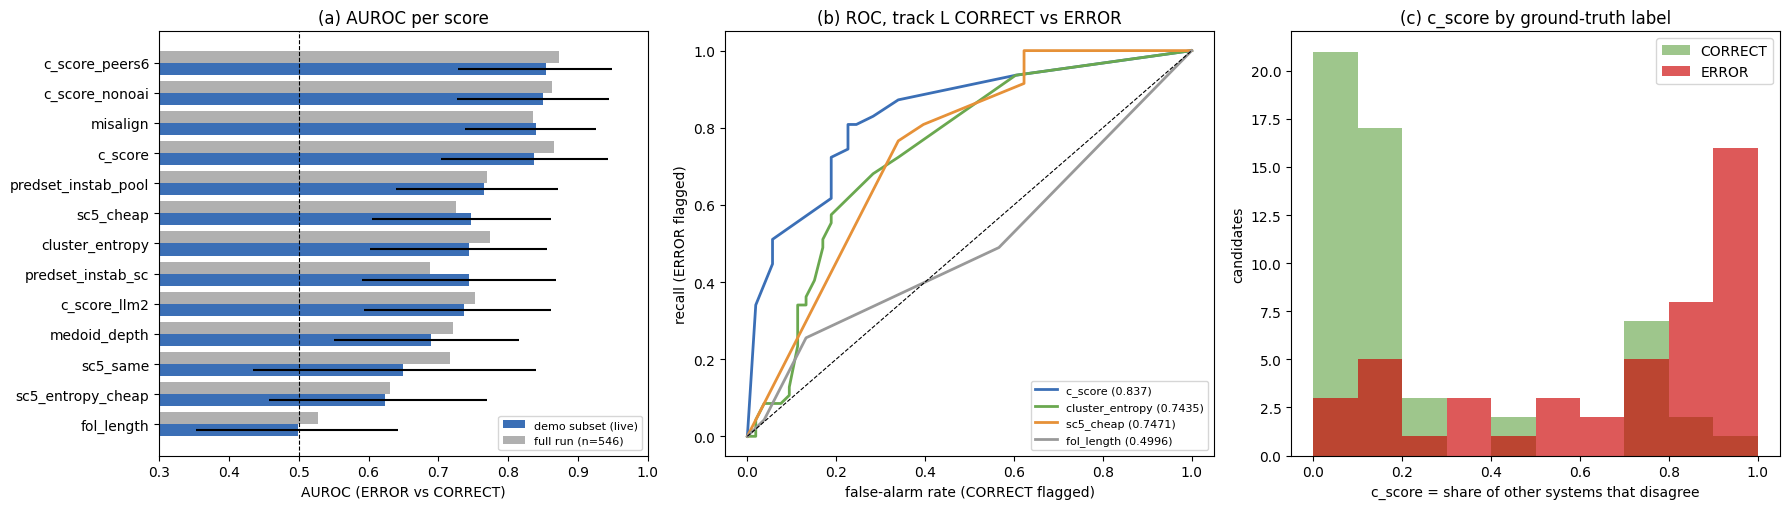

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

# (a) AUROC per score, demo vs full run
t = tab.dropna(subset=["demo_auroc"]).iloc[::-1]
yy = np.arange(len(t))
lo = [a - c[0] if c and c[0] is not None else 0 for a, c in zip(t["demo_auroc"], t["demo_ci95"])]
hi = [c[1] - a if c and c[1] is not None else 0 for a, c in zip(t["demo_auroc"], t["demo_ci95"])]
axes[0].barh(yy - 0.2, t["demo_auroc"], height=0.4, xerr=[lo, hi], color="#3b6fb6", label="demo subset (live)")
axes[0].barh(yy + 0.2, t["full_auroc"].fillna(0), height=0.4, color="#b0b0b0", label="full run (n=546)")
axes[0].axvline(0.5, color="k", lw=0.8, ls="--")
axes[0].set_yticks(yy, t["score"])
axes[0].set_xlim(0.3, 1.0)
axes[0].set_xlabel("AUROC (ERROR vs CORRECT)")
axes[0].set_title("(a) AUROC per score")
axes[0].legend(loc="lower right", fontsize=8)

# (b) ROC curves of the primary metric and the baselines
for sc, col in (("c_score", "#3b6fb6"), ("cluster_entropy", "#6aa84f"), ("sc5_cheap", "#e69138"), ("fol_length", "#999999")):
    d = P[P[sc].notna()]
    f_, t_, _ = roc_curve(d["y"], d[sc])
    axes[1].plot(f_, t_, color=col, lw=2, label=f"{sc} ({res[sc].get('auroc')})")
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].set_xlabel("false-alarm rate (CORRECT flagged)")
axes[1].set_ylabel("recall (ERROR flagged)")
axes[1].set_title("(b) ROC, track L CORRECT vs ERROR")
axes[1].legend(fontsize=8, loc="lower right")

# (c) c_score distribution by label
bins_ = np.linspace(0, 1, 11)
axes[2].hist(P[P["y"] == 0]["c_score"], bins=bins_, alpha=0.65, color="#6aa84f", label="CORRECT")
axes[2].hist(P[P["y"] == 1]["c_score"], bins=bins_, alpha=0.65, color="#cc0000", label="ERROR")
axes[2].set_xlabel("c_score = share of other systems that disagree")
axes[2].set_ylabel("candidates")
axes[2].set_title("(c) c_score by ground-truth label")
axes[2].legend()
plt.tight_layout()
plt.show()

### Example rows

For a few candidates we show the text, the candidate formula, the ground-truth label, the consensus score, and the error type the medoid repair guessed.

**Caveats from the full run.** About 38% of real errors are *endorsed* by the consensus, meaning most other systems make the same mistake. The metric also rests on the same `align()` routine the labeller uses. A vocab-clean subset controls for that (AUROC 0.852 there). Predicate or constant *renaming* to synonyms breaks the aligner and causes 96% false alarms. z3-equivalent rewrites flip 0% of verdicts, by construction.

In [21]:
show = P.sort_values("c_score")[["label", "repair_ops", "c_score", "medoid_depth", "medoid_ops", "sc5_cheap", "text", "candidate_fol"]]
with pd.option_context("display.max_colwidth", 70, "display.width", 250):
    print(pd.concat([show.head(4), show.tail(6)]).to_string(index=False))

  label   repair_ops  c_score  medoid_depth   medoid_ops  sc5_cheap                                                                 text                                          candidate_fol
CORRECT           []      0.0             0           []        0.0                                    All four-sided things are shapes.                           ∀x (FourSided(x) → Shape(x))
  ERROR       [BIND]      0.0             0           []        0.6                         The world championships is a sporting event.                      SportingEvent(worldChampionships)
CORRECT           []      0.0             0           []        0.0                     If something is a household appliance, it sucks.                   ∀x (HouseholdAppliance(x) → Suck(x))
CORRECT           []      0.0             0           []        0.2                                         Strikers are soccer players.                      ∀x (Striker(x) → SoccerPlayer(x))
  ERROR        [ADD]      1.0           